In [1]:
from torchvision import transforms


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # for RGB images
])

In [3]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

data_dir = "AutismDataset"

train_data = ImageFolder(root=f"{data_dir}/train", transform=transform)
val_data = ImageFolder(root=f"{data_dir}/valid", transform=transform)
test_data = ImageFolder(root=f"{data_dir}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)
print("Class-to-index mapping:", train_data.class_to_idx)
print("Total training images:", len(train_data))


Classes: ['Autistic', 'NonAutistic']
Class-to-index mapping: {'Autistic': 0, 'NonAutistic': 1}
Total training images: 2540


In [4]:
import torch.nn as nn

class ASDClassifierCNN(nn.Module):
    def __init__(self):
        super(ASDClassifierCNN, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 1),  # 28x28 is size after 3 poolings from 224x224
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


In [5]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ASDClassifierCNN().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [6]:
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = (outputs > 0.5).int()
            correct += (predicted == labels.int()).sum().item()
            total += labels.size(0)

        accuracy = correct / total * 100
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - Train Acc: {accuracy:.2f}%")

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
                outputs = model(inputs)
                predicted = (outputs > 0.5).int()
                val_correct += (predicted == labels.int()).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total * 100
        print(f"Validation Acc: {val_acc:.2f}%\n")


In [7]:
train_model(model, train_loader, val_loader, epochs=5)


Epoch 1/5 - Loss: 50.0703 - Train Acc: 65.71%
Validation Acc: 69.00%

Epoch 2/5 - Loss: 43.1764 - Train Acc: 71.57%
Validation Acc: 69.00%

Epoch 3/5 - Loss: 40.4956 - Train Acc: 76.02%
Validation Acc: 72.00%

Epoch 4/5 - Loss: 37.9298 - Train Acc: 77.36%
Validation Acc: 73.00%

Epoch 5/5 - Loss: 34.9278 - Train Acc: 80.12%
Validation Acc: 75.00%



In [8]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            predicted = (outputs > 0.5).int()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (predicted == labels.int()).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100
    print(f"Test Accuracy: {accuracy:.2f}%")
    return all_labels, all_preds


In [9]:
y_true, y_pred = evaluate(model, test_loader)


Test Accuracy: 74.33%


['Autistic', 'NonAutistic']
              precision    recall  f1-score   support

    Autistic       0.72      0.81      0.76       150
 NonAutistic       0.78      0.68      0.73       150

    accuracy                           0.74       300
   macro avg       0.75      0.74      0.74       300
weighted avg       0.75      0.74      0.74       300



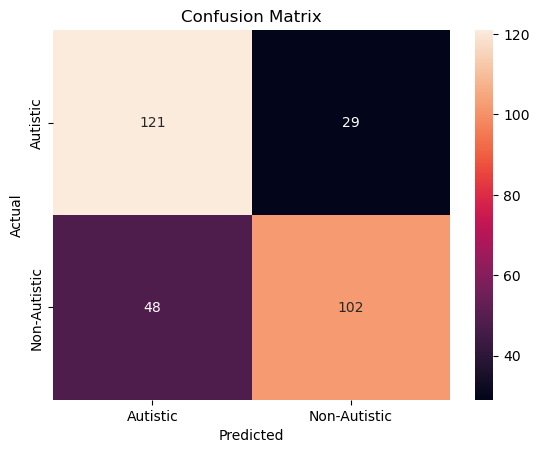

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

target_names = train_data.classes
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Autistic", "NonAutistic"], yticklabels=["Autistic","NonAutistic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
# Save
torch.save(model.state_dict(), 'asd_cnn_model.pth')

# Load
model = ASDClassifierCNN().to(device)
model.load_state_dict(torch.load('asd_cnn_model.pth'))
model.eval()


ASDClassifierCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=100352, out_features=1, bias=True)
    (11): Sigmoid()
  )
)